<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Week 10, Lesson 18 -- Deeper CNNs: Regularization, Metrics, and Feature Maps
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    From Accuracy to Precision/Recall -- Evaluating a Fault Detector Like an Engineer
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>10 of 16 -- CNNs for Geoscience</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Duration:</strong></td><td>40 minutes</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Phase:</strong></td><td>Month 3 -- Deep Learning</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Audience:</strong></td><td>Engineers &middot; Geoscientists &middot; Researchers</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Instructor:</strong></td><td>Dr. Daniel Wamriew</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Contact:</strong></td><td>wamriewdan@gmail.com</td>
    </tr>
  </table>
</div>

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### How to Use This Notebook

Work through this notebook **from top to bottom**, pressing **Shift + Enter** on each cell to run it.

- **Code cells** contain Python -- run them and read the output carefully.
- **Markdown cells** (white background) contain explanations -- read before running the next cell.
- **Student Activity** cells are marked `Activity` -- complete these before the homework.

This lesson builds directly on Lesson 17. The seismic-patch generator is redefined below so this
notebook runs standalone -- you do not need to re-open Lesson 17 first.
</div>

---
## Table of Contents

1. [Recap: What Lesson 17 Built](#1-recap-what-lesson-17-built)
2. [Why Depth Helps: Hierarchical Features](#2-why-depth-helps-hierarchical-features)
3. [A Larger, Noisier Seismic Dataset](#3-a-larger-noisier-seismic-dataset)
4. [A Deeper CNN Architecture](#4-a-deeper-cnn-architecture)
5. [Overfitting and Dropout](#5-overfitting-and-dropout)
6. [Training with a Validation Set](#6-training-with-a-validation-set)
7. [Beyond Accuracy: Precision, Recall, and the Confusion Matrix](#7-beyond-accuracy-precision-recall-and-the-confusion-matrix)
8. [Visualizing Feature Maps](#8-visualizing-feature-maps)
9. [Student Activity](#9-student-activity)
10. [Recap & Homework](#10-recap--homework)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Device:", torch.device("cpu"))

PyTorch version: 2.13.0+cu130
Device: cpu


---
## 1. Recap: What Lesson 17 Built

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Last lesson, in order:

- **Convolution**, by hand: slide a small kernel, multiply-and-sum, produce a feature map.
- **Pooling**: max over small windows, shrinking the feature map while keeping the strongest signal.
- `nn.Conv2d` / `nn.MaxPool2d` / `nn.Flatten` -- the vectorized, *learnable* PyTorch versions.
- A synthetic seismic fault dataset, and a 2-block CNN trained with `nn.BCEWithLogitsLoss()` that
  reached roughly 90% test accuracy.

Today we ask two engineering questions the last lesson skipped: **is a deeper network actually
better**, and **is "accuracy" even the right number to optimize for a safety-relevant detection
task**?
</div>

---
## 2. Why Depth Helps: Hierarchical Features

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Stacking convolution blocks builds a **hierarchy of features**, the same way a geologist's eye works
when interpreting a seismic section:

| Layer | Typically learns to detect | Geological analogy |
|---|---|---|
| Conv block 1 | Simple edges and local brightness changes | Individual reflector wiggles |
| Conv block 2 | Combinations of edges -- corners, short segments | A break in one reflector |
| Conv block 3 | Combinations of those -- larger, more abstract shapes | A fault surface cutting several reflectors |

Each pooling step also **enlarges the receptive field** -- the region of the original image that a
single output value "sees." A neuron in block 3 responds to a much larger patch of the input image
than a neuron in block 1, which is exactly what's needed to recognize a pattern (a fault) that spans
many pixels.
</div>

---
## 3. A Larger, Noisier Seismic Dataset

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Same generator as Lesson 17, redefined here so this notebook is self-contained. This time we
generate **more patches**, with **more noise** and a **smaller, more subtle fault offset** --
closer to what a real, harder detection problem looks like -- and split into train / validation /
test sets (60% / 20% / 20%) so we can watch for overfitting in Section 6.
</div>

In [2]:
def make_seismic_patch(size=64, n_layers=6, fault=False, fault_shift=4.0, noise=0.10, rng=None):
    """Generate one synthetic seismic patch (wavy layered reflectors, optional fault offset)."""
    rng = rng or np.random.default_rng()
    img = np.zeros((size, size))

    depths = np.sort(rng.uniform(6, size - 6, size=n_layers))
    amps = rng.uniform(0.6, 1.0, size=n_layers) * rng.choice([-1.0, 1.0], size=n_layers)
    dip = rng.uniform(-0.12, 0.12)
    wave_amp = rng.uniform(0.5, 2.5)
    wave_freq = rng.uniform(0.06, 0.15)
    idx = np.arange(size)

    for col in range(size):
        shift = dip * col + wave_amp * np.sin(wave_freq * col)
        col_depths = depths + shift
        if fault and col >= size // 2:
            col_depths = col_depths + fault_shift
        for d, a in zip(col_depths, amps):
            img[:, col] += a * np.exp(-((idx - d) ** 2) / (2 * 1.4 ** 2))

    img += rng.normal(0, noise, size=(size, size))
    return img


def make_dataset(n_per_class=200, rng=None, **patch_kwargs):
    rng = rng or np.random.default_rng(0)
    images, labels = [], []
    for _ in range(n_per_class):
        images.append(make_seismic_patch(fault=False, rng=rng, **patch_kwargs))
        labels.append(0)
        images.append(make_seismic_patch(fault=True, rng=rng, **patch_kwargs))
        labels.append(1)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)

rng = np.random.default_rng(42)
X, y = make_dataset(n_per_class=400, rng=rng, fault_shift=4.0, noise=0.10)
print("Dataset shape:", X.shape)
print("Class balance:", np.bincount(y.astype(int)))

Dataset shape: (800, 64, 64)
Class balance: [400 400]


In [3]:
from sklearn.model_selection import train_test_split

# First split off the test set, then split the remainder into train/validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
# 0.25 of the remaining 80% = 20% of the total -- so the final split is 60/20/20

def to_tensors(X_arr, y_arr):
    return torch.tensor(X_arr).unsqueeze(1), torch.tensor(y_arr).view(-1, 1)

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t, y_val_t = to_tensors(X_val, y_val)
X_test_t, y_test_t = to_tensors(X_test, y_test)

print(f"Train: {X_train_t.shape[0]} patches")
print(f"Val:   {X_val_t.shape[0]} patches")
print(f"Test:  {X_test_t.shape[0]} patches")

Train: 480 patches
Val:   160 patches
Test:  160 patches


---
## 4. A Deeper CNN Architecture

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Three convolution blocks this time (8 -> 16 -> 32 channels), each halving the spatial size:
64 -> 32 -> 16 -> 8. A `nn.Dropout` sits between the flattened features and the final dense layers
-- more on that in Section 5.
</div>

In [4]:
model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),    # 64x64 -> 64x64, 1 -> 8 channels
    nn.ReLU(),
    nn.MaxPool2d(2),                              # -> 32x32

    nn.Conv2d(8, 16, kernel_size=3, padding=1),   # -> 32x32, 8 -> 16 channels
    nn.ReLU(),
    nn.MaxPool2d(2),                              # -> 16x16

    nn.Conv2d(16, 32, kernel_size=3, padding=1),  # -> 16x16, 16 -> 32 channels
    nn.ReLU(),
    nn.MaxPool2d(2),                              # -> 8x8

    nn.Flatten(),                                 # 32 x 8 x 8 = 2048 values
    nn.Dropout(0.3),
    nn.Linear(32 * 8 * 8, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.3, inplace=False)
  (11): Linear(in_features=2048, out_features=64, bias=True)
  (12): ReLU()
  (13): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 137,089


---
## 5. Overfitting and Dropout

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

**Overfitting** (Lesson 4's bias-variance idea, now in a deep network) happens when the model starts
memorizing quirks of the training patches instead of learning the general fault pattern -- training
loss keeps falling while validation loss climbs back up.

`nn.Dropout(p=0.3)` randomly zeroes 30% of the values flowing through it **during training only**,
forcing the network to not rely too heavily on any single neuron. This is why `model.train()` and
`model.eval()` matter more today than in Lesson 16: dropout is active in `train()` mode and switched
off in `eval()` mode, where the full network is used for a stable prediction.
</div>

---
## 6. Training with a Validation Set

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Same four-step training loop as before, but now every epoch we also evaluate on the **validation
set** (never used for gradient updates) so we can watch the train/validation gap -- our early-warning
sign of overfitting.
</div>

In [5]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 40
train_losses, val_losses, val_accs = [], [], []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = loss_fn(val_logits, y_val_t)
        val_preds = (val_logits > 0).float()
        val_acc = (val_preds == y_val_t).float().mean().item()
    val_losses.append(val_loss.item())
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs}  |  train loss = {loss.item():.4f}  |  "
              f"val loss = {val_loss.item():.4f}  |  val acc = {val_acc:.3f}")

Epoch   5/40  |  train loss = 0.6854  |  val loss = 0.6877  |  val acc = 0.600


Epoch  10/40  |  train loss = 0.6606  |  val loss = 0.6674  |  val acc = 0.637


Epoch  15/40  |  train loss = 0.6051  |  val loss = 0.6164  |  val acc = 0.700


Epoch  20/40  |  train loss = 0.5216  |  val loss = 0.5083  |  val acc = 0.837


Epoch  25/40  |  train loss = 0.4021  |  val loss = 0.3753  |  val acc = 0.919


Epoch  30/40  |  train loss = 0.2874  |  val loss = 0.2534  |  val acc = 0.981


Epoch  35/40  |  train loss = 0.1853  |  val loss = 0.1565  |  val acc = 1.000


Epoch  40/40  |  train loss = 0.0931  |  val loss = 0.0945  |  val acc = 1.000


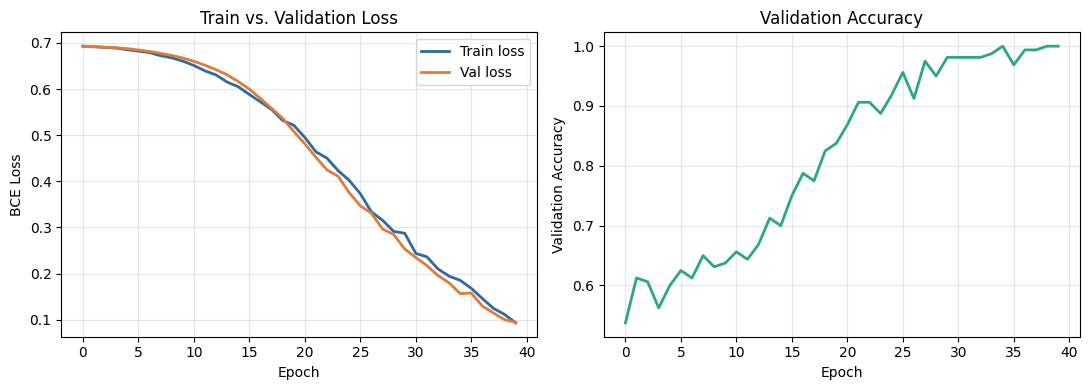

If train loss keeps dropping while val loss flattens or rises, that gap is overfitting --
the signal to add more dropout, simplify the model, or gather more training patches.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, label="Train loss", color="#2d6a9f", linewidth=2)
axes[0].plot(val_losses, label="Val loss", color="#e07b39", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Train vs. Validation Loss")

axes[1].plot(val_accs, color="#2ca87f", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy"); axes[1].grid(alpha=0.3)
axes[1].set_title("Validation Accuracy")
plt.tight_layout()
plt.show()
print("If train loss keeps dropping while val loss flattens or rises, that gap is overfitting --")
print("the signal to add more dropout, simplify the model, or gather more training patches.")

---
## 7. Beyond Accuracy: Precision, Recall, and the Confusion Matrix

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

For fault detection, **not all mistakes cost the same**. Missing a real fault (a **false negative**)
can mean drilling through unrecognized structural risk. A false alarm (a **false positive**) costs
an engineer a few minutes of extra review. Accuracy treats both errors as equal -- it usually isn't
the metric that matters most.

| Metric | Formula (TP/FP/FN/TN) | Answers |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of the patches we flagged as faulted, how many really were? |
| **Recall** | TP / (TP + FN) | Of the patches that really had a fault, how many did we catch? |
| **F1 score** | harmonic mean of precision and recall | A single balance number |

For a safety-relevant detector, **recall** is usually the number to protect first, even at some cost
to precision.
</div>

Test accuracy:  0.988
Test precision: 1.000  (of patches flagged 'fault', fraction actually faulted)
Test recall:    0.975  (of patches truly faulted, fraction we caught)
Test F1 score:  0.987


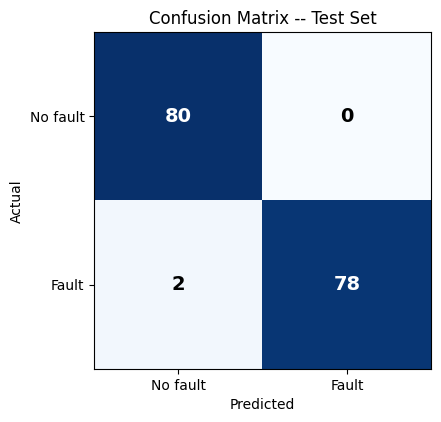

In [7]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_preds = (test_logits > 0).float()

y_true = y_test_t.numpy().flatten()
y_pred = test_preds.numpy().flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Test accuracy:  {acc:.3f}")
print(f"Test precision: {prec:.3f}  (of patches flagged 'fault', fraction actually faulted)")
print(f"Test recall:    {rec:.3f}  (of patches truly faulted, fraction we caught)")
print(f"Test F1 score:  {f1:.3f}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No fault", "Fault"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No fault", "Fault"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix -- Test Set")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Visualizing Feature Maps

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

We can pass one test image through only the first few layers of the model and look at the resulting
feature maps -- this is literally what the network "sees" at each stage. `model[:3]` slices out the
first convolution block (`Conv2d -> ReLU -> MaxPool2d`); `model[:6]` includes the second block too.
</div>

Input:             torch.Size([1, 1, 64, 64])
After block 1:     torch.Size([1, 8, 32, 32])  (8 feature maps, 32x32 each)
After block 2:     torch.Size([1, 16, 16, 16])  (16 feature maps, 16x16 each)


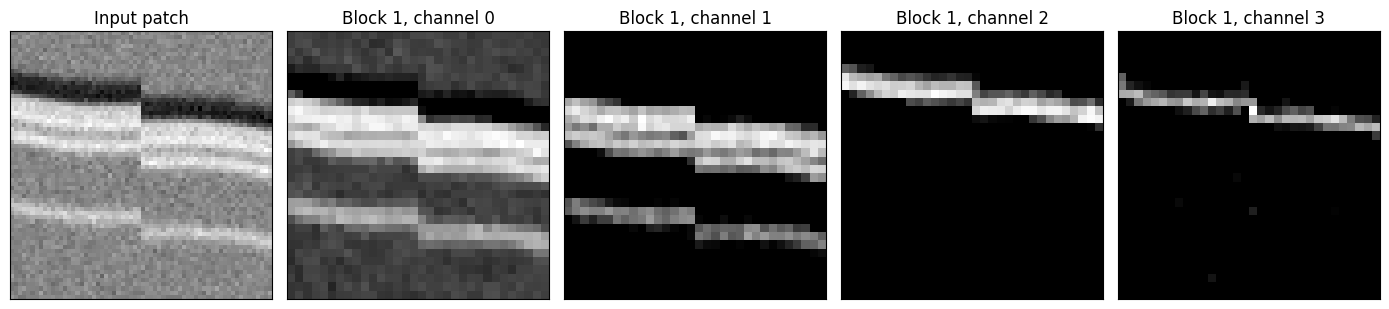

Different channels highlight different parts of the layering / fault pattern --
each one is a different learned kernel, exactly like Lesson 17 Section 3, but tuned by training.


In [8]:
# Pick one faulted test patch to inspect
fault_idx = np.where(y_test == 1)[0][0]
sample = X_test_t[fault_idx:fault_idx+1]   # keep the batch dimension: shape (1, 1, 64, 64)

model.eval()
with torch.no_grad():
    block1_out = model[:3](sample)   # after Conv2d -> ReLU -> MaxPool2d  (block 1)
    block2_out = model[:6](sample)   # after block 1 and block 2

print("Input:            ", sample.shape)
print("After block 1:    ", block1_out.shape, " (8 feature maps, 32x32 each)")
print("After block 2:    ", block2_out.shape, " (16 feature maps, 16x16 each)")

fig, axes = plt.subplots(1, 5, figsize=(14, 3.2))
axes[0].imshow(sample[0, 0], cmap="gray", aspect="auto")
axes[0].set_title("Input patch")
for k in range(4):
    axes[k+1].imshow(block1_out[0, k], cmap="gray", aspect="auto")
    axes[k+1].set_title(f"Block 1, channel {k}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()
print("Different channels highlight different parts of the layering / fault pattern --")
print("each one is a different learned kernel, exactly like Lesson 17 Section 3, but tuned by training.")

---
## 9. Student Activity

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Activity: Move the Decision Threshold

We have been calling a patch "fault" whenever the logit is greater than 0 (equivalent to a sigmoid
probability greater than 0.5). Recompute predictions using `torch.sigmoid(test_logits)` and two other
thresholds:

- **Threshold 0.3** (more sensitive -- flags more patches as faulted)
- **Threshold 0.7** (more conservative -- flags fewer patches as faulted)

For each threshold, recompute precision, recall, and F1 with `precision_score` / `recall_score` /
`f1_score`. Which threshold would you pick if missing a real fault were the costlier mistake?
</div>

In [9]:
# Activity -- recompute predictions at two other thresholds and compare precision/recall
# Hint: probs = torch.sigmoid(test_logits).numpy().flatten()
#       preds_at_threshold = (probs > threshold).astype(float)





---
## 10. Recap & Homework

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### What You Learned

| Concept | Meaning |
|---------|---------|
| Hierarchical features | Deeper conv blocks combine simple patterns (edges) into complex ones (fault shapes) |
| Receptive field | The region of the original image a single output value is influenced by; grows with depth and pooling |
| `nn.Dropout` | Randomly zeroes activations during training only, to reduce overfitting |
| Train/val/test split | Validation set monitors overfitting during training; test set gives the final, honest score |
| Precision / Recall / F1 | Metrics that separate "false alarm" errors from "missed detection" errors |
| Feature map visualization | Slicing `nn.Sequential` (`model[:3]`) to inspect what an intermediate layer produces |

</div>

### Homework

**Task 1 -- Regularize Differently**

Rebuild the Section 4 model with `nn.Dropout(0.5)` instead of `0.3`, and add `nn.BatchNorm2d(8)`,
`nn.BatchNorm2d(16)`, `nn.BatchNorm2d(32)` right after each `Conv2d` (before the `ReLU`). Retrain and
compare the train/validation loss gap to the Section 6 baseline. Did either change reduce overfitting?

**Task 2 -- Precision-Recall Curve**

Loop `threshold` from 0.1 to 0.9 in steps of 0.1. At each threshold, compute precision and recall on
the test set (reuse the Section 9 activity code) and store the results. Plot precision and recall
(y-axis) against threshold (x-axis) on the same figure, and report the threshold that maximizes F1.

**Task 3 (Engineering) -- A Related Task**

One of this course's assigned readings covers **CNN-based dip estimation** -- predicting a
*continuous angle* rather than a fault / no-fault label. Modify `make_seismic_patch` to also return
the `dip` value used to generate each patch, and sketch (in a markdown cell, no code required) how
you would change Section 4's final layer and Section 6's loss function to predict dip angle instead
of fault presence.

In [10]:
# Homework Task 1 -- Regularize Differently
# Hint: rebuild model with Dropout(0.5) and a BatchNorm2d after each Conv2d, fresh optimizer,
#       reuse the Section 6 training loop (track train_losses/val_losses again).





In [11]:
# Homework Task 2 -- Precision-Recall Curve
# Hint: probs = torch.sigmoid(test_logits).numpy().flatten()
#       for t in np.arange(0.1, 1.0, 0.1): preds = (probs > t).astype(float); ...





**Homework Task 3 (Engineering) -- your written sketch goes here.**

*(No code required -- describe in 3-5 sentences how the architecture and loss function would change
for a dip-angle regression task instead of fault classification.)*

<div style="background: #1a3a5c; color: white; padding: 22px 26px; border-radius: 10px; margin-top: 18px;">
  <h3 style="margin-top: 0; color: #ffffff;">Lesson Complete</h3>
  <p style="margin-bottom: 0; color: #d8ecff;">
    You built a deeper CNN, watched dropout fight overfitting on a train/validation split, and
    learned why precision and recall matter more than accuracy for a safety-relevant detector. Next
    week, Lesson 19 leaves static images behind and opens <strong>Time-Series &amp; Sequential
    Models</strong> -- RNNs and LSTMs -- applied to forecasting oil and gas production rates over time.
  </p>
</div>